In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 4)

df = pd.read_parquet('/Users/anish/Documents/demand forcasting time series /data/raw_clean_for_fetureeng/orders_clean.parquet')
print("Shape:", df.shape)
df.head(2)

Shape: (368999, 13)


,order_id,store_id,hub_id,channel_id,order_status,order_amount,order_moment_created,hub_name,hub_city,hub_state,store_segment,channel_name,channel_type
0,68405119,3512,75,5,CANCELED,62.7,2021-01-01 00:01:36,PYTHON SHOPPING,CURITIBA,PR,FOOD,FOOD PLACE,MARKETPLACE
1,68405123,3512,75,5,CANCELED,62.7,2021-01-01 00:04:26,PYTHON SHOPPING,CURITIBA,PR,FOOD,FOOD PLACE,MARKETPLACE


In [2]:
df = df[df['order_status'] == 'FINISHED'].copy()
print("Rows after keeping only FINISHED:", len(df))

Rows after keeping only FINISHED: 352020


In [3]:
df['order_moment_created'] = pd.to_datetime(df['order_moment_created'])
print("Range:", df['order_moment_created'].min(), "→", df['order_moment_created'].max())

Range: 2021-01-01 02:32:51 → 2021-04-30 23:59:48


In [4]:
df['ts'] = df['order_moment_created'].dt.floor('H')
df[['order_id','hub_id','order_moment_created','ts']].head()

/var/folders/bg/c56hl8bn35xd6x1rywnkcx780000gn/T/ipykernel_1402/4183763569.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['ts'] = df['order_moment_created'].dt.floor('H')


,order_id,hub_id,order_moment_created,ts
8,68410055,13,2021-01-01 02:32:51,2021-01-01 02:00:00
17,68412721,28,2021-01-01 14:12:11,2021-01-01 14:00:00
18,68413340,28,2021-01-01 14:14:51,2021-01-01 14:00:00
19,68414018,37,2021-01-01 14:17:31,2021-01-01 14:00:00
20,68414309,13,2021-01-01 14:21:02,2021-01-01 14:00:00


In [5]:
hourly = (df.groupby(['hub_id','ts'])['order_id']
            .nunique()
            .reset_index(name='orders'))
hourly.head()

,hub_id,ts,orders
0,3,2021-01-01 21:00:00,11
1,3,2021-01-01 22:00:00,16
2,3,2021-01-01 23:00:00,26
3,3,2021-01-02 00:00:00,40
4,3,2021-01-02 01:00:00,7


In [6]:
all_hubs  = hourly['hub_id'].unique()
all_hours = pd.date_range(hourly['ts'].min(), hourly['ts'].max(), freq='H')

print("Hubs :", len(all_hubs))
print("Hours:", len(all_hours))
print("Expected total rows:", len(all_hubs) * len(all_hours))

Hubs : 28
Hours: 2878
Expected total rows: 80584


/var/folders/bg/c56hl8bn35xd6x1rywnkcx780000gn/T/ipykernel_1402/3785707395.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours = pd.date_range(hourly['ts'].min(), hourly['ts'].max(), freq='H')


In [7]:
full_idx = pd.MultiIndex.from_product([all_hubs, all_hours], names=['hub_id','ts'])
hourly   = hourly.set_index(['hub_id','ts']).reindex(full_idx, fill_value=0).reset_index()

print("Shape after filling zeros:", hourly.shape)
print("Zero-order hours:", (hourly['orders'] == 0).sum(),
      "(", round((hourly['orders']==0).mean()*100, 1), "%)")
hourly.head()

Shape after filling zeros: (80584, 3)
Zero-order hours: 43914 ( 54.5 %)


,hub_id,ts,orders
0,3,2021-01-01 02:00:00,0
1,3,2021-01-01 03:00:00,0
2,3,2021-01-01 04:00:00,0
3,3,2021-01-01 05:00:00,0
4,3,2021-01-01 06:00:00,0


In [8]:
hourly = hourly.sort_values(['hub_id','ts']).reset_index(drop=True)
hourly.head()

,hub_id,ts,orders
0,3,2021-01-01 02:00:00,0
1,3,2021-01-01 03:00:00,0
2,3,2021-01-01 04:00:00,0
3,3,2021-01-01 05:00:00,0
4,3,2021-01-01 06:00:00,0


In [9]:
zero_share = hourly.groupby('hub_id')['orders'].apply(lambda s: (s == 0).mean()).sort_values()
zero_share.describe()


count    28.000000
mean      0.544947
std       0.148448
min       0.348853
25%       0.486015
50%       0.505559
75%       0.542651
max       0.999305
Name: orders, dtype: float64

In [10]:
print("Rows in hourly       :", len(hourly))
print("Unique hubs remaining:", hourly['hub_id'].nunique())
print("Zero-order rows      :", (hourly['orders'] == 0).sum())
print("Zero-order share     :", (hourly['orders'] == 0).mean().round(3))

Rows in hourly       : 80584
Unique hubs remaining: 28
Zero-order rows      : 43914
Zero-order share     : 0.545


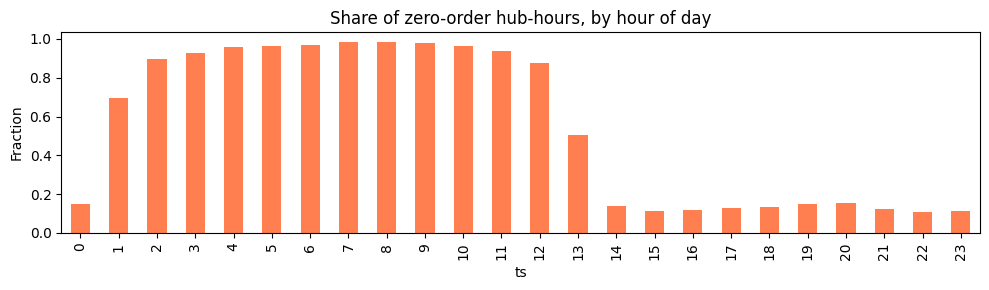

In [11]:
zero_by_hour = hourly.groupby('hour' if 'hour' in hourly.columns 
                              else hourly['ts'].dt.hour)['orders'].apply(lambda s: (s == 0).mean())

plt.figure(figsize=(10,3))
zero_by_hour.plot(kind='bar', color='coral')
plt.title('Share of zero-order hub-hours, by hour of day')
plt.ylabel('Fraction'); plt.tight_layout(); plt.show()

In [12]:
hub_totals = hourly.groupby('hub_id', observed=True)['orders'].sum().sort_values()
print("Bottom 5 hubs by total orders:")
print(hub_totals.head())
print("\nTop 5 hubs by total orders:")
print(hub_totals.tail())

Bottom 5 hubs by total orders:
hub_id
73       2
86     183
85    3215
42    4441
22    4592
Name: orders, dtype: int64

Top 5 hubs by total orders:
hub_id
3     20280
13    20603
31    22364
29    22530
8     42994
Name: orders, dtype: int64


In [13]:
# Keep hubs with at least ~5 orders/day → 500 over ~105 days
active_hubs = hub_totals[hub_totals >= 500].index

before = len(hourly)
hourly = hourly[hourly['hub_id'].isin(active_hubs)].reset_index(drop=True)

print(f"\nDropped {before - len(hourly):,} rows from inactive hubs")
print("Hubs kept:", hourly['hub_id'].nunique())
print("Rows kept:", len(hourly))


Dropped 5,756 rows from inactive hubs
Hubs kept: 26
Rows kept: 74828


In [14]:
hourly['orders'].value_counts()

orders
0      38231
1       3976
2       3505
3       3109
4       3009
       ...  
71         1
86         1
100        1
66         1
81         1
Name: count, Length: 85, dtype: int64

In [15]:
hourly.columns

Index(['hub_id', 'ts', 'orders'], dtype='object')

In [16]:
hub_info = df[['hub_id','hub_name','hub_city','hub_state']].drop_duplicates('hub_id')
hourly = hourly.merge(hub_info, on='hub_id', how='left')
hourly.head()

,hub_id,ts,orders,hub_name,hub_city,hub_state
0,3,2021-01-01 02:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS
1,3,2021-01-01 03:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS
2,3,2021-01-01 04:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS
3,3,2021-01-01 05:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS
4,3,2021-01-01 06:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS


In [17]:
seg = df.groupby('hub_id')['store_segment'].agg(lambda s: s.value_counts().index[0]).reset_index()
seg.columns = ['hub_id','hub_dominant_segment']
hourly = hourly.merge(seg, on='hub_id', how='left')
hourly.head()

,hub_id,ts,orders,hub_name,hub_city,hub_state,hub_dominant_segment
0,3,2021-01-01 02:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD
1,3,2021-01-01 03:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD
2,3,2021-01-01 04:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD
3,3,2021-01-01 05:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD
4,3,2021-01-01 06:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD


In [18]:
ch = df.groupby('hub_id')['channel_type'].agg(lambda s: s.value_counts().index[0]).reset_index()
ch.columns = ['hub_id','hub_dominant_channel']
hourly = hourly.merge(ch, on='hub_id', how='left')
hourly.head()

,hub_id,ts,orders,hub_name,hub_city,hub_state,hub_dominant_segment,hub_dominant_channel
0,3,2021-01-01 02:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE
1,3,2021-01-01 03:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE
2,3,2021-01-01 04:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE
3,3,2021-01-01 05:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE
4,3,2021-01-01 06:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE


In [19]:
hourly['hour']       = hourly['ts'].dt.hour
hourly['dow']        = hourly['ts'].dt.dayofweek
hourly['day']        = hourly['ts'].dt.day
hourly['month']      = hourly['ts'].dt.month
hourly['week']       = hourly['ts'].dt.isocalendar().week.astype(int)
hourly['is_weekend'] = (hourly['dow'] >= 5).astype(int)
hourly.head()

,hub_id,ts,orders,hub_name,hub_city,hub_state,hub_dominant_segment,hub_dominant_channel,hour,dow,day,month,week,is_weekend
0,3,2021-01-01 02:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE,2,4,1,1,53,0
1,3,2021-01-01 03:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE,3,4,1,1,53,0
2,3,2021-01-01 04:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE,4,4,1,1,53,0
3,3,2021-01-01 05:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE,5,4,1,1,53,0
4,3,2021-01-01 06:00:00,0,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE,6,4,1,1,53,0


In [20]:
hourly['hour_sin'] = np.sin(2*np.pi*hourly['hour']/24)
hourly['hour_cos'] = np.cos(2*np.pi*hourly['hour']/24)
hourly['dow_sin']  = np.sin(2*np.pi*hourly['dow']/7)
hourly['dow_cos']  = np.cos(2*np.pi*hourly['dow']/7)
hourly[['hour','hour_sin','hour_cos','dow','dow_sin','dow_cos']].head()

,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
0,2,0.500000,8.660254e-01,4,-0.433884,-0.900969
1,3,0.707107,7.071068e-01,4,-0.433884,-0.900969
2,4,0.866025,5.000000e-01,4,-0.433884,-0.900969
3,5,0.965926,2.588190e-01,4,-0.433884,-0.900969
4,6,1.000000,6.123234e-17,4,-0.433884,-0.900969


In [21]:
hourly['is_active_window']  = (hourly['hour'].between(13, 23) | (hourly['hour'] == 0)).astype(int)
hourly['is_dead_window']    = hourly['hour'].between(2, 12).astype(int)
hourly['is_evening_peak']   = hourly['hour'].between(18, 22).astype(int)
hourly['is_late_night']     = (hourly['hour'].between(22, 23) | (hourly['hour'] == 0)).astype(int)

hourly[['hour','is_active_window','is_dead_window','is_evening_peak','is_late_night']].drop_duplicates().sort_values('hour')

,hour,is_active_window,is_dead_window,is_evening_peak,is_late_night
22,0,1,0,0,1
23,1,0,0,0,0
0,2,0,1,0,0
1,3,0,1,0,0
2,4,0,1,0,0
3,5,0,1,0,0
4,6,0,1,0,0
5,7,0,1,0,0
6,8,0,1,0,0
7,9,0,1,0,0


In [22]:
%pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [23]:
import holidays

br_holidays = holidays.country_holidays(
    'BR',
    years=[2021, 2022]
)

hourly['is_holiday'] = (
    hourly['ts'].dt.date.isin(br_holidays).astype(int)
)


print("Holiday hours:", hourly['is_holiday'].sum(),
      "(", round(hourly['is_holiday'].mean()*100, 2), "%)")

Holiday hours: 1820 ( 2.43 %)


In [24]:
hourly['is_payday_window'] = hourly['day'].isin([5, 6, 20, 21]).astype(int)
print("Payday-window hours share:", round(hourly['is_payday_window'].mean()*100, 1), "%")

Payday-window hours share: 13.3 %


In [25]:
hourly['lag_1']   = hourly.groupby('hub_id')['orders'].shift(1)
hourly['lag_24']  = hourly.groupby('hub_id')['orders'].shift(24)
hourly['lag_168'] = hourly.groupby('hub_id')['orders'].shift(168)

hourly[['hub_id','ts','orders','lag_1','lag_24','lag_168']].head(200).tail(5)

,hub_id,ts,orders,lag_1,lag_24,lag_168
195,3,2021-01-09 05:00:00,0,0.0,0.0,0.0
196,3,2021-01-09 06:00:00,0,0.0,0.0,0.0
197,3,2021-01-09 07:00:00,0,0.0,0.0,0.0
198,3,2021-01-09 08:00:00,0,0.0,0.0,0.0
199,3,2021-01-09 09:00:00,0,0.0,0.0,0.0


In [26]:
hourly['roll_mean_24']  = (hourly.groupby('hub_id')['orders']
                                 .shift(1).rolling(24).mean()
                                 .reset_index(0, drop=True))

hourly['roll_mean_168'] = (hourly.groupby('hub_id')['orders']
                                 .shift(1).rolling(168).mean()
                                 .reset_index(0, drop=True))

hourly[['ts','orders','roll_mean_24','roll_mean_168']].tail()

,ts,orders,roll_mean_24,roll_mean_168
74823,2021-04-30 19:00:00,3,1.625000,1.589286
74824,2021-04-30 20:00:00,2,1.625000,1.577381
74825,2021-04-30 21:00:00,4,1.666667,1.541667
74826,2021-04-30 22:00:00,11,1.625000,1.529762
74827,2021-04-30 23:00:00,15,1.875000,1.535714


In [27]:
hourly['roll_std_24']  = (hourly.groupby('hub_id')['orders']
                                .shift(1).rolling(24).std()
                                .reset_index(0, drop=True))

hourly['roll_std_168'] = (hourly.groupby('hub_id')['orders']
                                .shift(1).rolling(168).std()
                                .reset_index(0, drop=True))
hourly[['ts','orders','roll_std_24','roll_std_168']].tail()

,ts,orders,roll_std_24,roll_std_168
74823,2021-04-30 19:00:00,3,2.039022,2.208667
74824,2021-04-30 20:00:00,2,2.039022,2.195524
74825,2021-04-30 21:00:00,4,2.035910,2.138482
74826,2021-04-30 22:00:00,11,1.974016,2.118992
74827,2021-04-30 23:00:00,15,2.675371,2.144183


In [28]:
hourly['roll_max_24'] = (hourly.groupby('hub_id')['orders']
                               .shift(1).rolling(24).max()
                               .reset_index(0, drop=True))
hourly[['ts','orders','roll_max_24']].tail()

,ts,orders,roll_max_24
74823,2021-04-30 19:00:00,3,7.0
74824,2021-04-30 20:00:00,2,7.0
74825,2021-04-30 21:00:00,4,7.0
74826,2021-04-30 22:00:00,11,7.0
74827,2021-04-30 23:00:00,15,11.0


In [29]:
hourly['lag_336'] = hourly.groupby('hub_id')['orders'].shift(336)
hourly['same_hour_2w_mean'] = hourly[['lag_168','lag_336']].mean(axis=1)

hourly[['ts','orders','lag_168','lag_336','same_hour_2w_mean']].tail()

,ts,orders,lag_168,lag_336,same_hour_2w_mean
74823,2021-04-30 19:00:00,3,5.0,2.0,3.5
74824,2021-04-30 20:00:00,2,8.0,5.0,6.5
74825,2021-04-30 21:00:00,4,6.0,21.0,13.5
74826,2021-04-30 22:00:00,11,10.0,17.0,13.5
74827,2021-04-30 23:00:00,15,5.0,12.0,8.5


In [30]:
'''hourly['lag_336']  = hourly.groupby('hub_id')['orders'].shift(336)   # 2 weeks
hourly['lag_504']  = hourly.groupby('hub_id')['orders'].shift(504)   # 3 weeks
hourly['lag_672']  = hourly.groupby('hub_id')['orders'].shift(672)   # 4 weeks

hourly['same_hour_4w_mean'] = hourly[['lag_168','lag_336','lag_504','lag_672']].mean(axis=1)
hourly[['ts','orders','lag_168','lag_336','lag_504','lag_672','same_hour_4w_mean']].tail()'''

"hourly['lag_336']  = hourly.groupby('hub_id')['orders'].shift(336)   # 2 weeks\nhourly['lag_504']  = hourly.groupby('hub_id')['orders'].shift(504)   # 3 weeks\nhourly['lag_672']  = hourly.groupby('hub_id')['orders'].shift(672)   # 4 weeks\n\nhourly['same_hour_4w_mean'] = hourly[['lag_168','lag_336','lag_504','lag_672']].mean(axis=1)\nhourly[['ts','orders','lag_168','lag_336','lag_504','lag_672','same_hour_4w_mean']].tail()"

In [31]:
hub_totals_df = df.groupby('hub_id').size().reset_index(name='hub_total_orders')
hub_totals_df['hub_avg_hourly'] = hub_totals_df['hub_total_orders'] / len(all_hours)
hourly = hourly.merge(hub_totals_df, on='hub_id', how='left')
hourly[['hub_id','hub_total_orders','hub_avg_hourly']].drop_duplicates().head()

,hub_id,hub_total_orders,hub_avg_hourly
0,3,20280,7.046560
2878,8,42994,14.938846
5756,13,20603,7.158791
8634,16,18571,6.452745
11512,17,13234,4.598332


In [32]:
before = len(hourly)
hourly = hourly.dropna(subset=['lag_336','roll_mean_168']).reset_index(drop=True)
print(f"Dropped {before - len(hourly):,} rows lacking history.")
print("Final shape:", hourly.shape)
print("Unique hubs:", hourly['hub_id'].nunique())

Dropped 8,736 rows lacking history.
Final shape: (66092, 36)
Unique hubs: 26


In [33]:
hourly.columns

Index(['hub_id', 'ts', 'orders', 'hub_name', 'hub_city', 'hub_state',
       'hub_dominant_segment', 'hub_dominant_channel', 'hour', 'dow', 'day',
       'month', 'week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'is_active_window', 'is_dead_window', 'is_evening_peak',
       'is_late_night', 'is_holiday', 'is_payday_window', 'lag_1', 'lag_24',
       'lag_168', 'roll_mean_24', 'roll_mean_168', 'roll_std_24',
       'roll_std_168', 'roll_max_24', 'lag_336', 'same_hour_2w_mean',
       'hub_total_orders', 'hub_avg_hourly'],
      dtype='object')

In [34]:
hourly['hub_id']               = hourly['hub_id'].astype('category')
hourly['hub_city']             = hourly['hub_city'].astype('category')
hourly['hub_state']            = hourly['hub_state'].astype('category')
hourly['hub_dominant_segment'] = hourly['hub_dominant_segment'].astype('category')
hourly['hub_dominant_channel'] = hourly['hub_dominant_channel'].astype('category')
hourly.dtypes

hub_id                        category
ts                      datetime64[ns]
orders                           int64
hub_name                        object
hub_city                      category
hub_state                     category
hub_dominant_segment          category
hub_dominant_channel          category
hour                             int32
dow                              int32
day                              int32
month                            int32
week                             int64
is_weekend                       int64
hour_sin                       float64
hour_cos                       float64
dow_sin                        float64
dow_cos                        float64
is_active_window                 int64
is_dead_window                   int64
is_evening_peak                  int64
is_late_night                    int64
is_holiday                       int64
is_payday_window                 int64
lag_1                          float64
lag_24                   

In [35]:
sample_hub = hourly['hub_id'].unique()[0]
hourly[hourly['hub_id'] == sample_hub].head(3).T

,0,1,2
hub_id,3,3,3
ts,2021-01-15 02:00:00,2021-01-15 03:00:00,2021-01-15 04:00:00
orders,4,4,0
hub_name,GREEN SHOPPING,GREEN SHOPPING,GREEN SHOPPING
hub_city,PORTO ALEGRE,PORTO ALEGRE,PORTO ALEGRE
hub_state,RS,RS,RS
hub_dominant_segment,FOOD,FOOD,FOOD
hub_dominant_channel,MARKETPLACE,MARKETPLACE,MARKETPLACE
hour,2,3,4
dow,4,4,4


In [36]:
print("Rows              :", len(hourly))
print("Unique hubs       :", hourly['hub_id'].nunique())
print("Date range        :", hourly['ts'].min(), "→", hourly['ts'].max())
print("Total features    :", hourly.shape[1] - 3)
print("Missing values    :", hourly.isna().sum().sum())
print("Target zero-share :", round((hourly['orders']==0).mean()*100, 1), "%")

Rows              : 66092
Unique hubs       : 26
Date range        : 2021-01-15 02:00:00 → 2021-04-30 23:00:00
Total features    : 33
Missing values    : 0
Target zero-share : 50.3 %


In [37]:
sample = hourly[hourly['hub_id'] == hourly['hub_id'].unique()[0]].reset_index(drop=True)

check_1   = (sample['lag_1'].iloc[1:].values     == sample['orders'].iloc[:-1].values).mean()
check_24  = (sample['lag_24'].iloc[24:].values   == sample['orders'].iloc[:-24].values).mean()
check_168 = (sample['lag_168'].iloc[168:].values == sample['orders'].iloc[:-168].values).mean()

print(f"lag_1   integrity: {check_1*100:.1f}%   (must be 100%)")
print(f"lag_24  integrity: {check_24*100:.1f}%   (must be 100%)")
print(f"lag_168 integrity: {check_168*100:.1f}%   (must be 100%)")

lag_1   integrity: 100.0%   (must be 100%)
lag_24  integrity: 100.0%   (must be 100%)
lag_168 integrity: 100.0%   (must be 100%)


In [38]:
sample = hourly[hourly['hub_id'] == hourly['hub_id'].unique()[0]].reset_index(drop=True)

manual = sample['orders'].iloc[1:25].mean()
in_frame = sample['roll_mean_24'].iloc[25]
print(f"Manual mean of rows 1–24 : {manual:.4f}")
print(f"roll_mean_24 at row 25   : {in_frame:.4f}")
print("Match:", np.isclose(manual, in_frame))

Manual mean of rows 1–24 : 7.8333
roll_mean_24 at row 25   : 7.8333
Match: True


orders               1.000000
same_hour_2w_mean    0.872983
lag_168              0.849246
lag_24               0.835151
lag_336              0.828720
lag_1                0.731233
is_active_window     0.543585
hour                 0.434763
roll_mean_24         0.386231
roll_std_24          0.380338
roll_mean_168        0.373048
hub_avg_hourly       0.343983
dow                  0.072344
is_weekend           0.055780
is_holiday           0.032584
Name: orders, dtype: float64


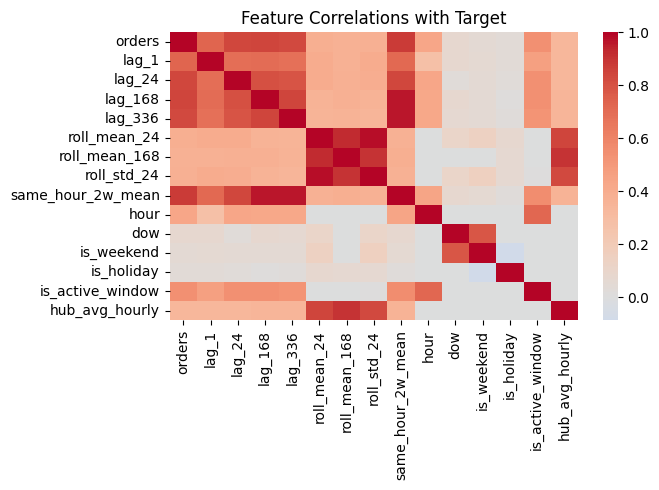

In [39]:
import seaborn as sns

num_cols = ['orders','lag_1','lag_24','lag_168','lag_336',
            'roll_mean_24','roll_mean_168','roll_std_24',
            'same_hour_2w_mean','hour','dow','is_weekend',
            'is_holiday','is_active_window','hub_avg_hourly']

corr = hourly[num_cols].corr()['orders'].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(7,5))
sns.heatmap(hourly[num_cols].corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlations with Target')
plt.tight_layout(); plt.show()

## Feature Engineering Summary

**Final feature table**
- 66,092 rows × 33 features × 26 hubs, 0 missing values
- ~106 days: Jan 15 → Apr 30, 2021
- Target: hourly order count, 50.3% zero-share (evening-active platform)

**Feature families**
- Calendar (6): hour, dow, day, month, week, is_weekend
- Cyclical (4): hour_sin/cos, dow_sin/cos
- Part-of-day flags (4): active_window, dead_window, evening_peak, late_night
- Special-day flags (2): is_holiday (BR), is_payday_window
- Lags (4): 1h, 24h, 168h (1w), 336h (2w)
- Rolling stats (5): mean_24/168, std_24/168, max_24
- Aggregates (1): same_hour_2w_mean
- Hub statics (7): hub_id, city, state, dominant_segment, dominant_channel,
  total_orders, avg_hourly

**Leakage validation**
All lag features verified with 100% integrity against shifted target;
rolling means verified against manual computation.

**Top predictors (raw correlation with target)**
same_hour_2w_mean (0.87), lag_168 (0.85), lag_24 (0.84), lag_336 (0.83)

In [40]:
hourly.to_parquet('/Users/anish/Documents/demand forcasting time series /data/processed/features.parquet', index=False)
print("Saved: features.parquet")
print("Shape:", hourly.shape)
print("Hubs :", hourly['hub_id'].nunique())

Saved: features.parquet
Shape: (66092, 36)
Hubs : 26
